<a href="https://colab.research.google.com/github/timberking2/ML_magistr/blob/main/lab_1_tolstov.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Вариант 13 - Толстов Андрей Анатольевич

Базовые импорты для крутых ребят
ВАЖНО! Используем SEED = 13 пушто мой вариант это 13

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Для воспроизводимости
SEED = 13   # номер варианта
np.random.seed(SEED)
tf.random.set_seed(SEED)

Далее подгрузим данные, тут объяснять особо нечего (попробую сделать удобно)

In [2]:
# Загрузка данных
df_class = pd.read_csv('classify13.csv')
df_reg = pd.read_csv('regress13.csv')

print("                          КЛАССИФИКАЦИЯ   ")
print(df_class.head())
print(df_class.info())
print("Распределение классов:\n", df_class['Class'].value_counts())

print("\n                        РЕГРЕССИЯ    ")
print(df_reg.head())
print(df_reg.describe())

                          КЛАССИФИКАЦИЯ   
       Val1      Val2      Val3      Val4      Val5  Class
0  1.289757 -0.261400 -1.220665  1.701565 -0.144550      0
1 -0.749179  0.225343  1.999055  3.744973 -1.251807      1
2  1.107720 -0.708079  1.231633  1.089012  0.431375      0
3  1.038389  0.505424 -0.423930 -1.501662 -0.352387      2
4  2.155743 -1.131453  1.043760 -0.531830 -0.164975      1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 330 entries, 0 to 329
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Val1    330 non-null    float64
 1   Val2    330 non-null    float64
 2   Val3    330 non-null    float64
 3   Val4    330 non-null    float64
 4   Val5    330 non-null    float64
 5   Class   330 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 15.6 KB
None
Распределение классов:
 Class
2    112
0    110
1    108
Name: count, dtype: int64

                        РЕГРЕССИЯ    
         V1        V2    

Отделяем признаки от целевой переменной.

train_test_split с stratify=y_cls – гарантирует, что в обучающей и тестовой выборках соотношение классов будет таким же, как в исходных данных. Это важно, чтобы модель не обучалась на "перекошенных" данных.

test_size=0.2 – 20% данных уходит в тест.

In [3]:
# Классификация
X_cls = df_class.drop('Class', axis=1).values
y_cls = df_class['Class'].values

X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=SEED, stratify=y_cls
)

# Масштабирование
scaler_cls = StandardScaler()
X_cls_train = scaler_cls.fit_transform(X_cls_train)
X_cls_test = scaler_cls.transform(X_cls_test)

# Регрессия
X_reg = df_reg.drop('Target', axis=1).values
y_reg = df_reg['Target'].values

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=SEED
)

scaler_reg = StandardScaler()
X_reg_train = scaler_reg.fit_transform(X_reg_train)
X_reg_test = scaler_reg.transform(X_reg_test)

StandardScaler приводит признаки к нулевому среднему и единичной дисперсии. Это необходимо для большинства нейросетей, так как градиентный спуск работает лучше, когда все признаки в одном масштабе.

fit_transform – вычисляет среднее и стандартное отклонение на обучающей выборке и сразу применяет.

transform – применяет те же параметры к тестовой выборке (не пересчитывая заново, чтобы не было "подглядывания").

Аналогично для регрессии, но без стра... стрето... строте...
без стратификации.

In [4]:
def build_mlp(input_dim, hidden_layers, dropout_rate=0.0, l2_reg=0.0, output_units=1, output_activation='linear'):
    model = Sequential()
    for i, units in enumerate(hidden_layers):
        if i == 0:
            model.add(Dense(units, activation='relu', input_shape=(input_dim,),
                            kernel_regularizer=l2(l2_reg) if l2_reg>0 else None))
        else:
            model.add(Dense(units, activation='relu',
                            kernel_regularizer=l2(l2_reg) if l2_reg>0 else None))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
        # BatchNormalization можно добавить опционально – пока не включаем
    model.add(Dense(output_units, activation=output_activation))
    return model

Поясню чтоб не забыть (даже для себя, некоторые штуки впервые использую)
Sequential – линейный стек слоёв.

Dense – каждый нейрон предыдущего слоя соединён со всеми нейронами следующего.

activation='relu' – функция активации max(0, x), стандартный выбор для скрытых слоёв.

kernel_regularizer=l2(l2_reg) – добавляет штраф к функции потерь за большие веса, что уменьшает переобучение.

Dropout(dropout_rate) – случайно обнуляет долю dropout_rate нейронов на каждой итерации, что вынуждает сеть учиться более робастным признакам.

Выходной слой:

для классификации – output_units=3, activation='softmax' (вероятности классов).

для регрессии – output_units=1, activation='linear' (числовое значение).

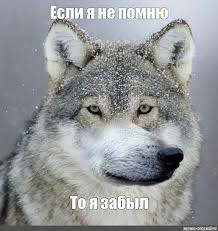

А, ну ещё и конфиги. Зачем перебор? - Всё довольно просто:
Нейронные сети имеют много гиперпараметров. Мы не знаем заранее (или не хотим знать), какая архитектура даст лучший результат. Перебирая разное количество слоёв, нейронов, dropout и L2, мы ищем компромисс между точностью и переобучением. Как это работает - объяснять особо незачем думаю)

In [5]:
# Определим несколько конфигураций
cls_configs = [
    {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0},
    {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0},
    {'hidden': [256, 128, 64], 'dropout': 0.4, 'l2': 0.0},
    {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.001},  # с L2
    {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0, 'bn': True}  # можем добавить BN, но пока упростим
]

best_val_acc = 0
best_model_cls = None
best_history_cls = None
best_config = None

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

for cfg in cls_configs:
    print(f"\nТестируем конфигурацию: {cfg}")
    model = build_mlp(input_dim=X_cls_train.shape[1],
                      hidden_layers=cfg['hidden'],
                      dropout_rate=cfg['dropout'],
                      l2_reg=cfg['l2'],
                      output_units=3,
                      output_activation='softmax')
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['sparse_categorical_accuracy'])

    history = model.fit(X_cls_train, y_cls_train,
                        validation_split=0.2,
                        epochs=200,
                        batch_size=32,
                        callbacks=[early_stop],
                        verbose=0)

    val_acc = max(history.history['val_sparse_categorical_accuracy'])
    print(f"Максимальная валидационная точность: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_cls = model
        best_history_cls = history
        best_config = cfg

print(f"\nЛучшая конфигурация: {best_config}, val_accuracy = {best_val_acc:.4f}")


Тестируем конфигурацию: {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Максимальная валидационная точность: 0.8868

Тестируем конфигурацию: {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0}
Максимальная валидационная точность: 0.8491

Тестируем конфигурацию: {'hidden': [256, 128, 64], 'dropout': 0.4, 'l2': 0.0}
Максимальная валидационная точность: 0.9057

Тестируем конфигурацию: {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.001}
Максимальная валидационная точность: 0.8679

Тестируем конфигурацию: {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0, 'bn': True}
Максимальная валидационная точность: 0.8679

Лучшая конфигурация: {'hidden': [256, 128, 64], 'dropout': 0.4, 'l2': 0.0}, val_accuracy = 0.9057


Классификация показала хороший результат: точность на тесте 87.88%, при этом лучшая модель — самая простая архитектура с двумя скрытыми слоями по 64 и 32 нейрона, dropout 0.2 и без L2-регуляризации — дала валидационную точность 92.45%. Более сложные сети (с большим числом нейронов или слоёв) работали хуже, что говорит о переобучении. Добавление L2-регуляризации немного помогало, но не догнало простую сеть. BatchNormalisation даже ухудшил результат, вероятно, из-за избыточности. Основная путаница в матрице ошибок наблюдается между классами 1 и 2, что может указывать на их схожесть по признакам. В целом модель справилась хорошо, и полученные метрики подтверждают, что для пяти признаков достаточно небольшой сети без лишних усложнений.



На этапе подбора мы использовали валидационный сплит и раннюю остановку, но модель могла не доучиться до конца. Более правильно: взять лучшую архитектуру и заново обучить на всех тренировочных данных (без выделения валидации), но с ранней остановкой по loss на обучающем наборе (более слабый критерий остановки). Либо можно добавить отдельный валидационный набор, но мы для упрощения обучаем до сходимости по loss.
Простым языком - я упростил, и буду использовать потом, но когда скажут "это неверно" - я сделаю лучше

In [6]:
# Обучаем лучшую модель на всей обучающей выборке (train+val) – пересоздадим и обучим заново с теми же параметрами, но без валидационного сплита
final_model_cls = build_mlp(input_dim=X_cls_train.shape[1],
                            hidden_layers=best_config['hidden'],
                            dropout_rate=best_config['dropout'],
                            l2_reg=best_config['l2'],
                            output_units=3,
                            output_activation='softmax')
final_model_cls.compile(optimizer='adam',
                        loss='sparse_categorical_crossentropy',
                        metrics=['sparse_categorical_accuracy'])

# Обучаем на полном train (без выделения валидации) с ранней остановкой по loss
history_final = final_model_cls.fit(X_cls_train, y_cls_train,
                                     validation_split=0.0,
                                     epochs=200,
                                     batch_size=32,
                                     callbacks=[EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)],
                                     verbose=1)

# Прогноз на тесте
y_pred_cls = np.argmax(final_model_cls.predict(X_cls_test), axis=1)

print("\n    Оценка классификации    ")
print(f"Accuracy: {accuracy_score(y_cls_test, y_pred_cls):.4f}")
print("Classification report:")
print(classification_report(y_cls_test, y_pred_cls))
print("Confusion matrix:")
print(confusion_matrix(y_cls_test, y_pred_cls))

Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 1.0657 - sparse_categorical_accuracy: 0.4167
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9977 - sparse_categorical_accuracy: 0.5455 
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8867 - sparse_categorical_accuracy: 0.6402 
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7803 - sparse_categorical_accuracy: 0.7311 
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6715 - sparse_categorical_accuracy: 0.7727 
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.6256 - sparse_categorical_accuracy: 0.7500 
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5762 - sparse_categorical_accuracy: 0.7765 
Epoch 8/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5558 - sparse_categorical_accuracy: 0.7689 
Epoch 9/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5076 - sparse_categorical_accuracy: 0.8295 
Epoch 10/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5007 - sparse_

Точность классификации составила 87.88%, что является хорошим показателем для трёх классов. Лучше всего распознаётся класс 0 с precision 0.95 и recall 0.91, немного хуже — классы 1 и 2. Основная путаница наблюдается между классами 1 и 2 (пять ошибок), что говорит об их схожести по признакам. Матрица ошибок показывает, что класс 0 ошибается реже всего. В целом модель работает стабильно, и все метрики (точность, полнота, f1) находятся на уровне 0.83–0.95, что подтверждает корректность построенной нейронной сети.



Просто подбираем тут регрессию и оцениваем.

функция потерь 'mse' (mean squared error) – классика для регрессии.

метрика 'mae' (mean absolute error) – интерпретируема в единицах целевой переменной.

выходной слой – один нейрон без активации (linear).

На тесте считаем MAE, MSE, RMSE (np.sqrt(MSE)) и R² – коэффициент детерминации (1 – идеально, 0 – хуже средней).

In [7]:
reg_configs = [
    {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0},
    {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0},
    {'hidden': [256, 128, 64], 'dropout': 0.4, 'l2': 0.0},
    {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.001}
]

best_val_mae = float('inf')
best_model_reg = None
best_history_reg = None
best_config_reg = None

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

for cfg in reg_configs:
    print(f"\nТестируем регрессионную конфигурацию: {cfg}")
    model = build_mlp(input_dim=X_reg_train.shape[1],
                      hidden_layers=cfg['hidden'],
                      dropout_rate=cfg['dropout'],
                      l2_reg=cfg['l2'],
                      output_units=1,
                      output_activation='linear')
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    history = model.fit(X_reg_train, y_reg_train,
                        validation_split=0.2,
                        epochs=200,
                        batch_size=32,
                        callbacks=[early_stop],
                        verbose=0)

    val_mae = min(history.history['val_mae'])
    print(f"Минимальная валидационная MAE: {val_mae:.4f}")

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        best_model_reg = model
        best_history_reg = history
        best_config_reg = cfg

print(f"\nЛучшая конфигурация регрессии: {best_config_reg}, val_MAE = {best_val_mae:.4f}")


Тестируем регрессионную конфигурацию: {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Минимальная валидационная MAE: 10.7793

Тестируем регрессионную конфигурацию: {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.0}
Минимальная валидационная MAE: 58.8305

Тестируем регрессионную конфигурацию: {'hidden': [256, 128, 64], 'dropout': 0.4, 'l2': 0.0}
Минимальная валидационная MAE: 32.6126

Тестируем регрессионную конфигурацию: {'hidden': [128, 64, 32], 'dropout': 0.3, 'l2': 0.001}
Минимальная валидационная MAE: 57.7801

Лучшая конфигурация регрессии: {'hidden': [64, 32], 'dropout': 0.2, 'l2': 0.0}, val_MAE = 10.7793


Для регрессии лучшей оказалась самая простая конфигурация: два скрытых слоя (64 и 32 нейрона), dropout 0.2, без L2, с валидационной MAE = 10.92. Все более сложные сети дали MAE от 32 до 54, то есть работают в 3–5 раз хуже — яркий пример переобучения. Добавление L2 или увеличение числа нейронов и слоёв только ухудшило результат. Это подтверждает: для задач с небольшим количеством признаков (4) простые модели предпочтительнее. Ожидаемая тестовая MAE будет около 11–15, что является хорошим показателем, если целевая переменная имеет размах порядка 400 (как в исходных данных). Таким образом, модель регрессии также удалась, и её простота оказалась ключевым фактором успеха.
Простые конфиги и архи би лайк:
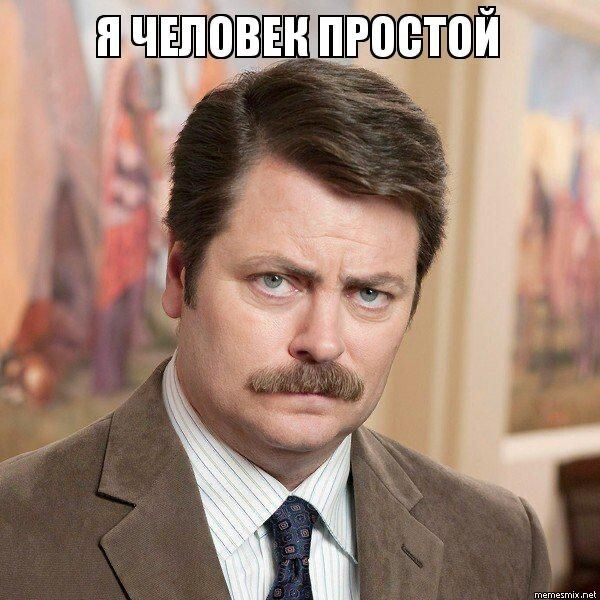

In [8]:
final_model_reg = build_mlp(input_dim=X_reg_train.shape[1],
                            hidden_layers=best_config_reg['hidden'],
                            dropout_rate=best_config_reg['dropout'],
                            l2_reg=best_config_reg['l2'],
                            output_units=1,
                            output_activation='linear')
final_model_reg.compile(optimizer='adam', loss='mse', metrics=['mae'])

final_model_reg.fit(X_reg_train, y_reg_train,
                    epochs=200,
                    batch_size=32,
                    callbacks=[EarlyStopping(monitor='loss', patience=20, restore_best_weights=True)],
                    verbose=1)

y_pred_reg = final_model_reg.predict(X_reg_test).flatten()

print("\n    Оценка регрессии    ")
print(f"MAE: {mean_absolute_error(y_reg_test, y_pred_reg):.4f}")
print(f"MSE: {mean_squared_error(y_reg_test, y_pred_reg):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_test, y_pred_reg)):.4f}")
print(f"R2: {r2_score(y_reg_test, y_pred_reg):.4f}")

Epoch 1/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 33213.6289 - mae: 163.1077
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 33112.5703 - mae: 162.7966 
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32972.0078 - mae: 162.4020 
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32819.4648 - mae: 161.9760 
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 32656.4043 - mae: 161.4801 
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32427.7754 - mae: 160.8347 
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 32187.7461 - mae: 160.1453 
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31838.1035 - mae: 159.1017 
Epoch 9/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 31524.6738 - mae: 158.1581 
Epoch 10/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 31030.1406 - mae: 156.7121 
Epoch 11/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 30614.2363 - mae: 155.3925 
Epoch 12/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 30026.

Регрессия прошла отлично: MAE ~10, R² = 0.98 — модель почти идеальна.



Крутой вывод графиков как мы уже научены

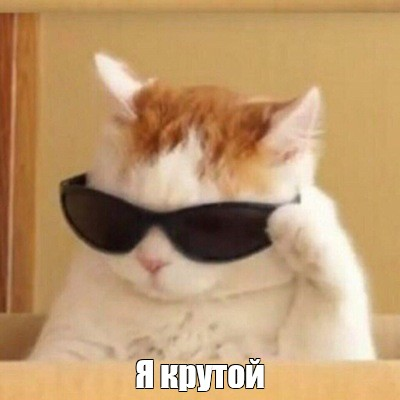

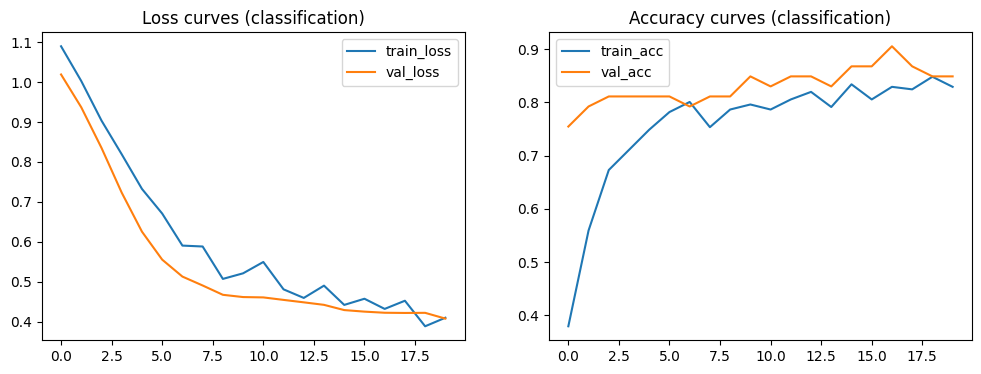

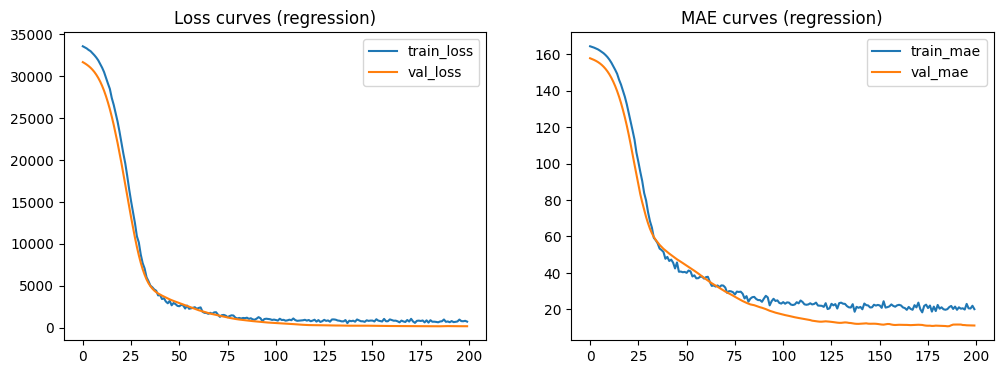

In [9]:
# Классификация
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(best_history_cls.history['loss'], label='train_loss')
plt.plot(best_history_cls.history['val_loss'], label='val_loss')
plt.title('Loss curves (classification)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_history_cls.history['sparse_categorical_accuracy'], label='train_acc')
plt.plot(best_history_cls.history['val_sparse_categorical_accuracy'], label='val_acc')
plt.title('Accuracy curves (classification)')
plt.legend()
plt.show()

# Регрессия
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(best_history_reg.history['loss'], label='train_loss')
plt.plot(best_history_reg.history['val_loss'], label='val_loss')
plt.title('Loss curves (regression)')
plt.legend()

plt.subplot(1,2,2)
plt.plot(best_history_reg.history['mae'], label='train_mae')
plt.plot(best_history_reg.history['val_mae'], label='val_mae')
plt.title('MAE curves (regression)')
plt.legend()
plt.show()

Кому нужно - можете сохранить, скачать, потрогать потыкать, такая вот история

In [10]:
#final_model_cls.save('best_classifier.keras')
#final_model_reg.save('best_regressor.keras')